<a href="https://colab.research.google.com/github/kenzoyanome/analisis_novaretail/blob/main/project_novaretail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
from scipy.stats import pointbiserialr, chi2_contingency

import warnings                                                  # MANEJO DE WARNINGS - ADVERTENCIAS
warnings.filterwarnings('ignore', category=FutureWarning)        # IGNORAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                       # ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                          # ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)                      # AUTOAJUSTA ANCHO DE COLUMNAS
pd.set_option('display.float_format', lambda x: '%.3f' % x)      # PERMITE EVADIR EL MOSTRAR NÚMEROS CON NOTACIÓN CINETÍFICA
plt.rcParams['figure.dpi'] = 140                                 # NIVEL DE RESOLUCIÓN.

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv("https://raw.githubusercontent.com/kenzoyanome/analisis_novaretail/refs/heads/main/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.000,28565.770,9,1,31.360,3.900,0,0,móvil,norte,23.220
1,CL-100001,36.000,29673.440,11,3,24.660,3.700,0,0,tablet,sur,93.470
2,CL-100002,46.000,30642.950,9,0,0.000,2.900,0,0,móvil,este,0.000
3,CL-100003,56.000,39468.610,8,0,6.810,3.100,0,0,móvil,este,0.000
4,CL-100004,35.000,22527.830,9,2,26.490,2.300,0,0,móvil,sur,33.760


## Sección 2 - Preparar datos y documentar supuestos

### 2.1. Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:  
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`  

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad necesita actualizarse a 'int64' para manejar solo numeros enteros  

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`  

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**, sin embargo pueden cambiarse a 'int8' que es más eficiente en memoria para variables binarias

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`  

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)
df[['miembro_premium', 'abandono']] = df[['miembro_premium', 'abandono']].astype('int8')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int8   
 8   abandono                   15000 non-null  int8   
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(3), int8(2), object(3)
memory usage: 1.2+ MB


#### 2.1.2. Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
v_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[v_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000
mean,38.262,30019.705,10.029,1.206,20.149,3.604,36.594
std,11.492,9833.166,3.158,1.105,10.881,0.685,34.485
min,18.000,8000.000,1.000,0.000,0.000,1.000,0.000
25%,30.000,23127.097,8.000,0.000,12.310,3.100,0.000
50%,38.000,30023.745,10.000,1.000,19.730,3.600,30.705
75%,46.000,36768.440,12.000,2.000,27.293,4.100,58.220
max,75.000,74790.840,25.000,8.000,75.510,5.000,244.690


✍️ Diagnóstico inicial de variables numéricas: no se muestran valores nulos, NA  

- `edad` - la media es muy parecida al p50, por lo tanto sin sesgos fuertes ni outliers evidentes, distribución bastante centrada.  
- `nivel_ingreso` - la media y la mediana se mantienen muy similares(≈30000), desviacion estandar alta, distribución relativamente estable.  
- `visitas_mes` - media = 10.029 y mediana = 10.000, el rango se mantiene estrecho entre 1 y 25 visitas.  
- `compras_mes` - la media y mediana son muy bajas (1-1.2) en comparacion a la media de visitas, el p25 muestra que un 25% de visitantes no compra nada.  
- `gasto_publicidad_dirigida` - la media y mediana ≈20 sin embargo tenemos valores maximos de 75.510, posibles outliers altos, algunos usuarios reciben mucha más inversión.  
- `satisfaccion` - media y mediana muy estables, satisfaccion moderadamente positiva, con opcion de mejoras.  
- `ingreso_anual` - la media > la mediana, 25% de valores en 0, fuerte sesgo a la derecha, posible variable inflada o mal distribuida.

#### 2.1.3. Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
v_binarias = ['miembro_premium', 'abandono']
df[v_binarias].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
Name: count, dtype: int64

✍️ Diagnóstico inicial de variables binarias

- `miembro_premium` - existen ≈14% de miembros premium, la myaoria de miembros no lo son, una clara oportunidad de mejora. Fuerte desbalance de clase, lo que puede afectar modelos predictivos o estrategias de segmentación
- `abandono` - la tasa de abandono ≈15%, miembros no premium tienen una mayor tasa de abandono

#### 2.1.4. Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
v_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
df[v_categoricas].nunique()

,0
id_cliente,15000
tipo_dispositivo,3
region,4


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in v_categoricas:
    if col == 'id_cliente':
        continue
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True))


tipo_dispositivo
tipo_dispositivo
móvil        0.655
escritorio   0.248
tablet       0.097
Name: proportion, dtype: float64

region
region
norte   0.293
oeste   0.254
sur     0.248
este    0.205
Name: proportion, dtype: float64


✍️ Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` - predomina el movil con un ≈65%, posteriormente el escritorio con un ≈25% y tablet con un ≈10%
- `region` - una distribucion parcialmente equilibrada, aun cuando la region norte es un poco mas dominante

### 2.2. Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones
Observamos cómo se relacionan las variables numéricas.

### 3.1. Heatmap

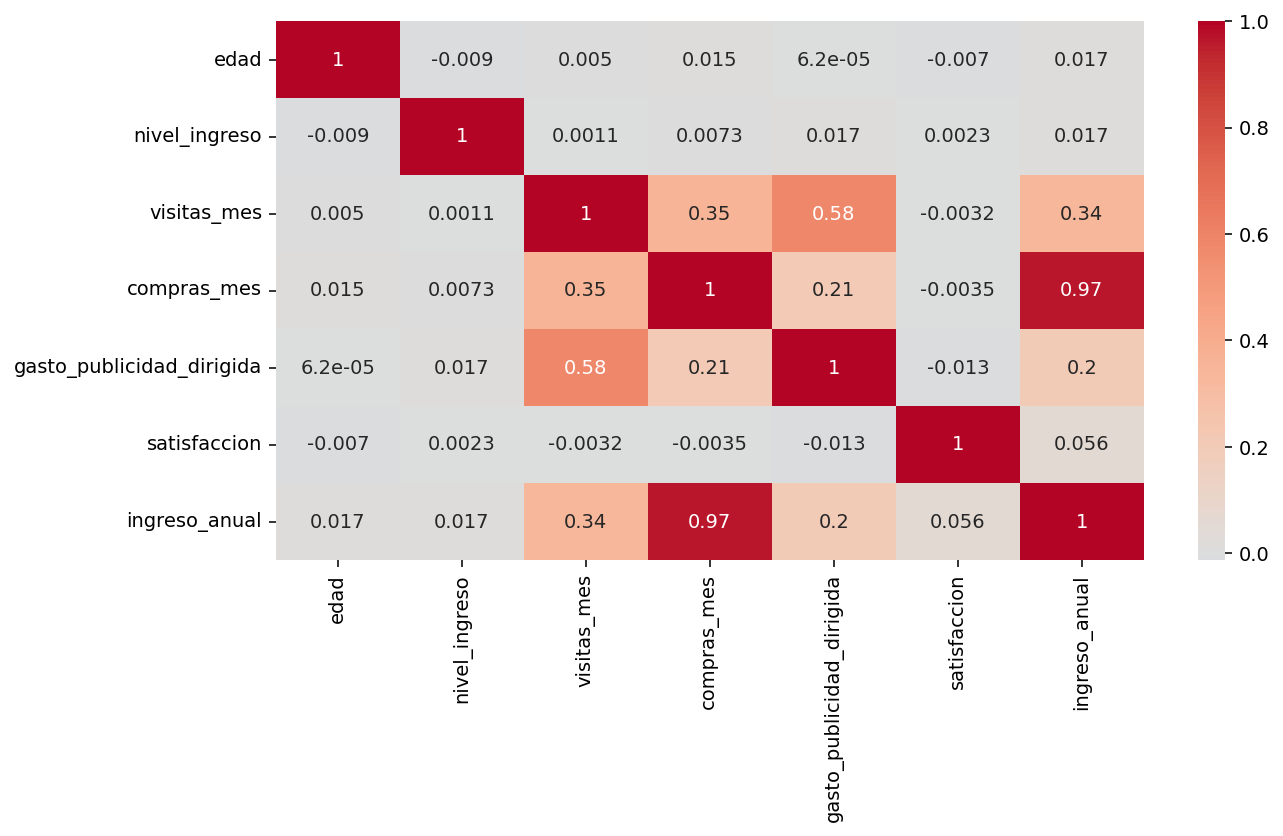

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
plt.figure(figsize=(10,5))
df_corr = df[v_numericas].corr()
sns.heatmap(df_corr,annot=True, cmap='coolwarm', center=0)
plt.show()

✍️ Observaciones generales (Heatmap)  
- Se observa que la mayoria de las variables tienen correlaciones cercanas a 0, lo cual nos indican que son independientes entre si.  
algunas correlaciones moderadas:
    - visitas - publicidad = 0.58  
    - visitas - compras    = 0.35  
      pareciera que la publicidad se asocia con mas visitas y a su vez con mas compras
parece que edad, nivel_ingreso y satisfaccion, no se ven asociadas con ninguna variable, las correlaciones son minimas

✍️ Observaciones respecto a `ingreso_anual`  
- Presenta una relacion demasiado alta con compras_mes (0.97), sin embargo ambas variables estan midiendo lo mismo, posible multicolinealidad
- tambien muestra una correlacion moderada con visitas (0.34) y publicidad (0.2), lo cual mostraria un flujo logico de funnel (publicidad → visitas → compras → ingreso)

### 3.2. Scatterplot general

<Figure size 1400x700 with 0 Axes>

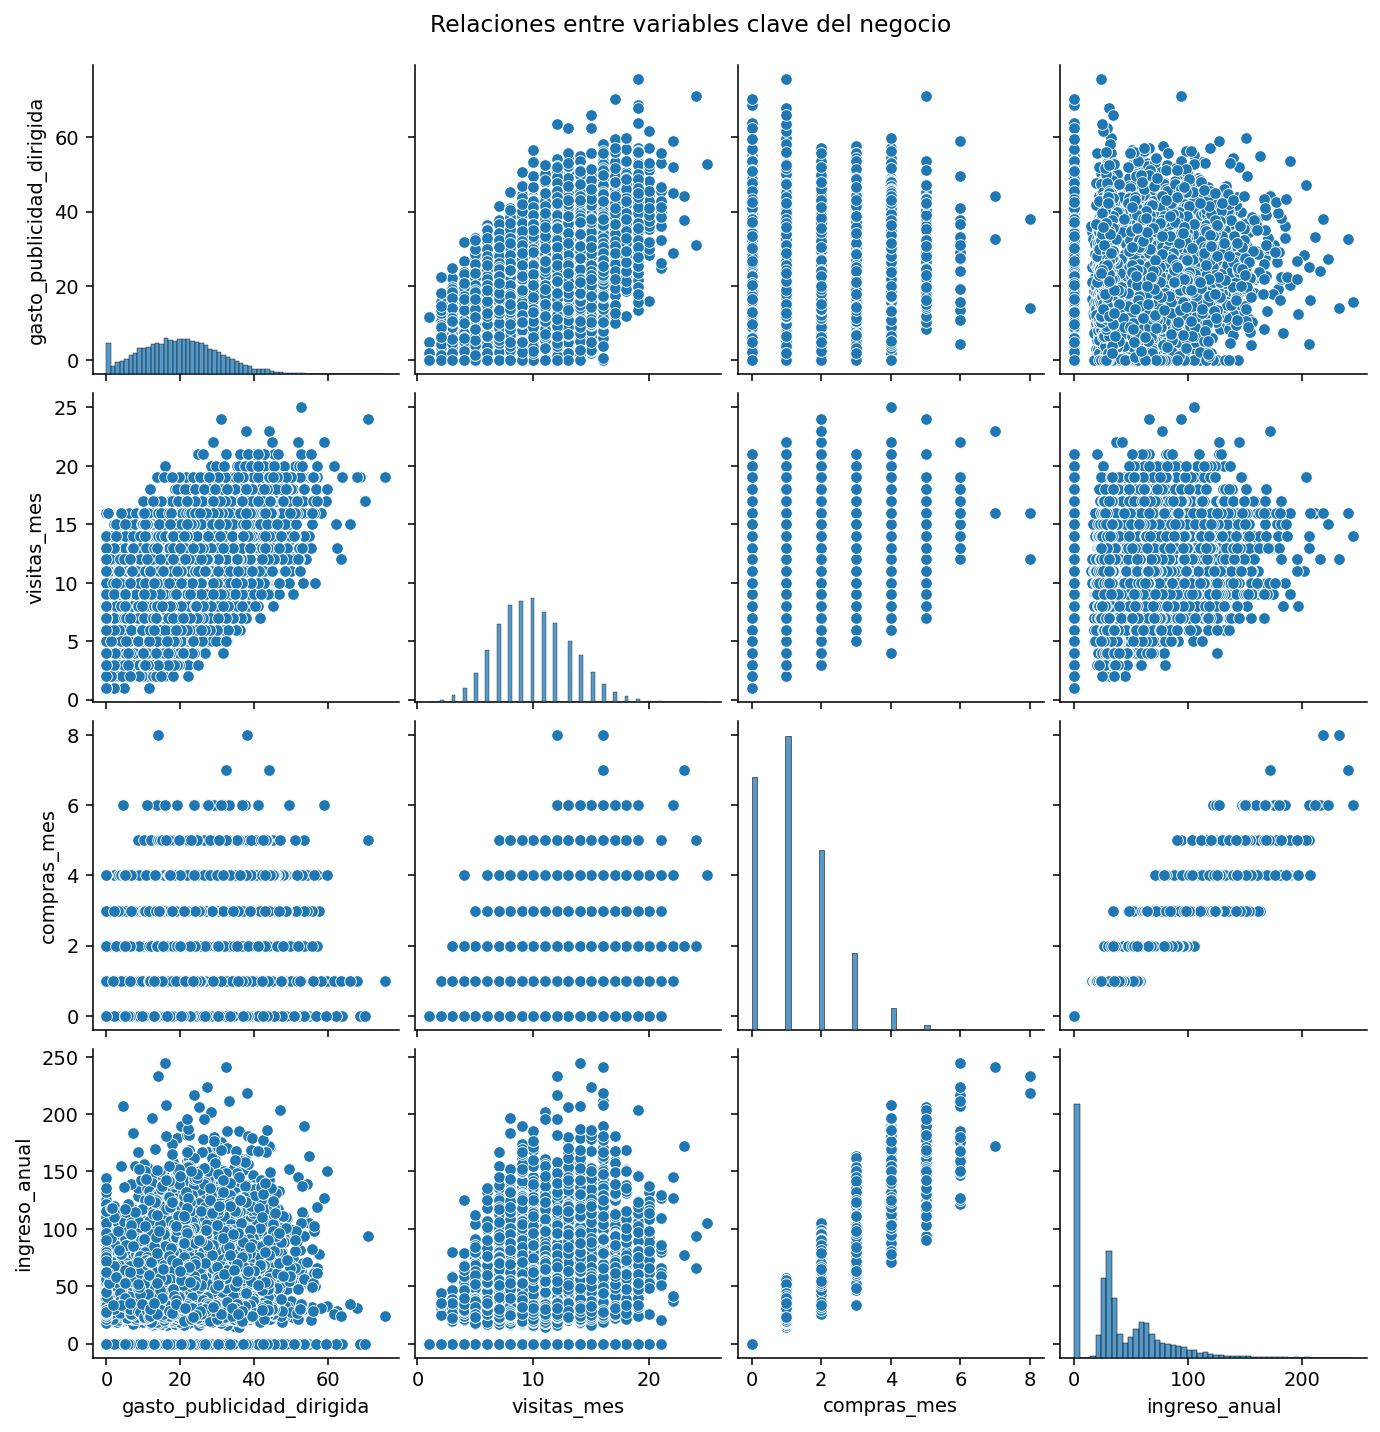

In [ ]:
#Se genera un scatterplot solo de las variables con correlacion considerable: 'gasto_publicidad_dirigida', 'visitas_mes', 'compras_mes', 'ingreso_anual'
# Visualizar pares de variables con relaciones moderadas o fuertes
v_scatter = ['gasto_publicidad_dirigida', 'visitas_mes', 'compras_mes', 'ingreso_anual']
plt.figure(figsize=(10,5))
sns.pairplot(df[v_scatter], diag_kind='hist')
plt.suptitle('Relaciones entre variables clave del negocio', y=1.02)
plt.show()


### 3.3. Scatterplot para pares clave

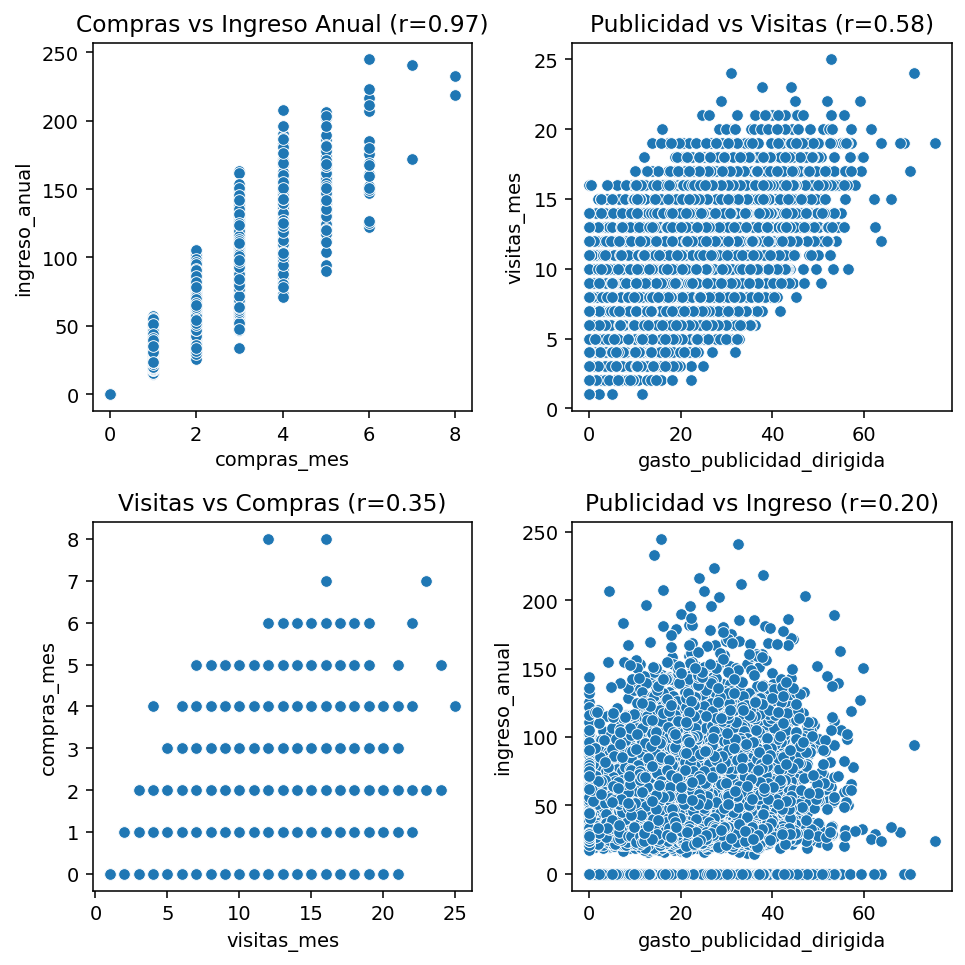

In [ ]:
# Crear subplots para mejor organización
fig, axes = plt.subplots(2, 2, figsize=(7,7))
# Confirmar si existe multicolinealidad (correlación 0.97)
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0,0])
axes[0,0].set_title('Compras vs Ingreso Anual (r=0.97)')
# Validar si publicidad genera visitas (correlación 0.58)
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', ax=axes[0,1])
axes[0,1].set_title('Publicidad vs Visitas (r=0.58)')
# Conversión de visitas a compras (correlación 0.35)
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', ax=axes[1,0])
axes[1,0].set_title('Visitas vs Compras (r=0.35)')
# Impacto final de publicidad vs ingreso total (correlación 0.20)
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', ax=axes[1,1])
axes[1,1].set_title('Publicidad vs Ingreso (r=0.20)')

plt.tight_layout()
plt.show()

✍️ Observaciones iniciales (Scatterplot)  
- **Compras vs Ingreso Anual:**
    - Dirección positiva, muy fuerte, casi lineal
    - Dispersion baja
    - Presencia de algunos outliers de valores altos pero consistentes con la tendencia
    - Colinealidad muy alta
- **Publicidad vs Visitas**
    - Dirección positiva moderada
    - Dispersion media
    - Presencia de algunos outliers con alto valor de publicidad y pocas visitas
    - Colinealidad moderada
- **Visitas vs Compras**
    - Dirección positiva debil, tendiendo a moderada
    - Dispersion alta
    - Presencia de algunos miembros con muchas visitas y pocas compras
    - Colinealidad baja
- **Publicidad vs Ingreso**
    - Dirección positiva pero debil
    - Dispersion alta
    - Se observan varios outliers (alto gasto con bajo ingreso y viceversa)
    - Colinealidad baja

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### 4.1. Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
print(v_scatter)
#df[variables_scatter].corr(method='pearson')
pearson = df[v_scatter].corr(method='pearson').style.background_gradient(cmap='winter')
pearson

['gasto_publicidad_dirigida', 'visitas_mes', 'compras_mes', 'ingreso_anual']


,gasto_publicidad_dirigida,visitas_mes,compras_mes,ingreso_anual
gasto_publicidad_dirigida,1.000000,0.578947,0.207528,0.197483
visitas_mes,0.578947,1.000000,0.353844,0.337147
compras_mes,0.207528,0.353844,1.000000,0.967149
ingreso_anual,0.197483,0.337147,0.967149,1.000000


In [ ]:
# Calcular correlación entre variables relevantes
spearman = df[v_scatter].corr(method='spearman').round(4).style.background_gradient(cmap='winter')
spearman

,gasto_publicidad_dirigida,visitas_mes,compras_mes,ingreso_anual
gasto_publicidad_dirigida,1.000000,0.559300,0.192500,0.185000
visitas_mes,0.559300,1.000000,0.332900,0.321000
compras_mes,0.192500,0.332900,1.000000,0.967500
ingreso_anual,0.185000,0.321000,0.967500,1.000000


✍️ Observaciones de correlación  
- **Compras vs Ingreso Anual:**
    - Direccion: positiva
    - Magnitud: muy alta (≈ 0.96–0.97)
    - Colinealidad: critica
    - Correlacion: casi perfecta, ambas variables son prácticamente redundantes
- **Publicidad vs Visitas**
    - Direccion: positiva
    - Magnitud: moderada (Pearson ≈ 0.58 | Spearman ≈ 0.56)
    - Colinealidad: no problemática
    - Correlacion: moderada, mayor inversión en publicidad tiende a generar más visitas, con cierta variabilidad
- **Visitas vs Compras**
    - Direccion: positiva
    - Magnitud: débil a moderada (≈ 0.33–0.35)
    - Colinealidad: baja
    - Correlacion: limitada, más visitas ayudan, pero no garantizan compras, se observa una fricción en conversión
- **Publicidad vs Ingreso / Publicidad vs Compras**
    - Direccion: positiva
    - Magnitud: débil (≈ 0.18–0.20)
    - Colinealidad: baja
    - Correlacion: débil, la publicidad no impacta directamente el ingreso
- **Visitas vs Ingreso**
    - Direccion: positiva
    - Magnitud: moderada (≈ 0.32–0.34)
    - Colinealidad: no problematica
    - Correlacion: intermedia, las visitas aportan al ingreso, pero indirectamente

### 4.2. Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
#v_binarias = ['miembro_premium', 'abandono']
for var_bin in v_binarias:
    print(f"\n--- Correlaciones con {var_bin} ---")
    for var_num in v_scatter:
        coef, p_value = pointbiserialr(df[var_bin], df[var_num])
        print(f"{var_bin} vs {var_num}: ")
        print(f" Point-Biserial: {coef:.4f}")
        print(f" P-value: {p_value:.4f}")


--- Correlaciones con miembro_premium ---
miembro_premium vs gasto_publicidad_dirigida: 
 Point-Biserial: 0.0027
 P-value: 0.7390
miembro_premium vs visitas_mes: 
 Point-Biserial: -0.0127
 P-value: 0.1211
miembro_premium vs compras_mes: 
 Point-Biserial: 0.0034
 P-value: 0.6744
miembro_premium vs ingreso_anual: 
 Point-Biserial: 0.0931
 P-value: 0.0000

--- Correlaciones con abandono ---
abandono vs gasto_publicidad_dirigida: 
 Point-Biserial: -0.0046
 P-value: 0.5744
abandono vs visitas_mes: 
 Point-Biserial: -0.0089
 P-value: 0.2734
abandono vs compras_mes: 
 Point-Biserial: 0.0083
 P-value: 0.3099
abandono vs ingreso_anual: 
 Point-Biserial: -0.0028
 P-value: 0.7295


✍️ Observaciones Punto-biserial  
- **miembro_premium vs gasto_publicidad_dirigida**
    - Direccion: positiva
    - Magnitud : baja (= 0.003)
    - Relación : inexistente - la inversión publicitaria no parece diferenciar entre premium y no premium
- **miembro_premium vs visitas_mes**
    - Direccion: negativa
    - Magnitud : baja (= -0.0127)
    - Relación : prácticamente nula - ser premium no implica más visitas
- **miembro_premium vs compras_mes**
    - Direccion: positiva
    - Magnitud : baja (= 0.0034)
    - Relación : nula - no hay evidencia de que los premium compren más frecuentemente
- **miembro_premium vs ingreso_anual**
    - Direccion: positiva
    - Magnitud : baja (= 0.0931)
    - Relación : débil pero significativa - ser premium está ligeramente asociado con mayor ingreso.

- **abandono  vs gasto_publicidad_dirigida**
    - Direccion: negativa
    - Magnitud : baja (= -0.0046)
    - Relación : inexistente - publicidad no influye directamente en abandono
- **abandono  vs visitas_mes**
    - Direccion: negativa
    - Magnitud : baja (= -0.0089)
    - Relación : nula - visitas no explican abandono
- **abandono  vs compras_mes**
    - Direccion: positiva
    - Magnitud : baja (= 0.0083)
    - Relación : muy débil - no hay evidencia clara de que más compras reduzcan abandono
- **abandono  vs ingreso_anual**
    - Direccion: negativa
    - Magnitud : baja (= -0.0028)
    - Relación : nula - ingresos no explican abandono directamente

### 4.3. V de Cramér

In [ ]:
# Función para calcular V de Cramér
col1 = 'id_cliente'
col2 = 'tipo_dispositivo'
col3 = 'region'
def cramers_v (df, col_1, col_2):
    tabla          = pd.crosstab(df[col_1], df[col_2])
    chi2, _, _, _  = chi2_contingency(tabla)
    n              = tabla.sum().sum()
    coef_v         = np.sqrt(chi2 / (n* (min(tabla.shape)-1)))
    print(f"Cramer's V {col_1} vs {col_2}: ", coef_v)

In [ ]:
# Aplicar V de Cramér en variables relevantes
cramers_v(df, col1, col2)
cramers_v(df, col1, col3)
cramers_v(df, col2, col3)

Cramer's V id_cliente vs tipo_dispositivo:  1.0
Cramer's V id_cliente vs region:  0.9999999999999999
Cramer's V tipo_dispositivo vs region:  0.012378338407739397


✍️ Observaciones V de Cramer
- id_cliente vs tipo_dispositivo: Relación perfecta (aparente)
    - No significa que exista relación real
    - Es un artefacto estadístico por alta cardinalidad
- id_cliente vs region: Relación perfecta (aparente)
    - Relación espuria
    - id_cliente no debe usarse en este tipo de análisis
- tipo_dispositivo vs region: Relación muy baja
    - Prácticamente no hay asociación entre ambas variables
    - La distribución de dispositivos es independiente de la región

## Sección 5 - Interpretación de resultados para el negocio

### El negocio sigue un funnel claro:
Publicidad → Visitas → Compras → Ingreso  
Pero:
- El mayor problema está en conversión (Visitas → Compras)
- El mayor driver de ingresos es compras (evidente multicolinealidad)
- El mayor driver de retención es premium  

El negocio no necesita más tráfico, necesita:
- Convertir mejor (visitas → compras)
- Retener mejor (premium)
- Enfocarse en el KPI correcto (compras)

### Hallazgo 1: El ingreso depende casi totalmente de las compras
- **Evidencia visual:**  
      Relacion lineal clara en el scatter compras vs ingreso_anual (patron casi perfecto)
- **Evidencia numérica:**  
      Correlacion ≈ 0.967 (muy alta)
- **Interpretación**  
      ingreso_anual depende directamente de compras_mes → variables practicamente redundantes
- **No podemos afirmar**  
      Que el aumento en compras sea la unica causa del ingreso (aunque es altamente consistente)
- **Implicación de negocio**  
      El KPI mas importante es incrementar compras  
      Las estrategias deben enfocarse en frecuencia de compra, no solo en el trafico

### Hallazgo 2: Existe un cuello de botella en la conversion (visitas → compras)
- **Evidencia visual:**  
      Alta dispersion en visitas vs compras (muchos usuarios visitan pero no compran)
- **Evidencia numérica:**  
      Correlacion ≈ 0.35 (debil a moderada)
- **Interpretación**  
      Hay friccion en el proceso de conversion → el trafico no se traduce eficientemente en ventas
- **No podemos afirmar**  
      La causa especifica (UX, precios, confianza, producto, etc.)
- **Implicación de negocio**  
      Existe una buena oportunidad en optimizar la conversion  
      Mejoras en checkout, UX y oferta pueden generar alto impacto en ingresos

### Hallazgo 3: Ser premium esta asociado con menor abandono
- **Evidencia visual:**  
      Los usuarios premium tienen una tasa de abandono mucho menor (~4% vs ~17%)
- **Evidencia numérica:**  
      Diferencia clara en proporciones (aunque correlación lineal baja ≈ 0.09)
- **Interpretación**  
      miembro_premium actua como factor de retencion
- **No podemos afirmar**  
      Que convertir a premium cause directamente menor abandono (puede haber sesgo de seleccion)
- **Implicación de negocio**  
      Estrategia clave: convertir usuarios a premium
      Programas de fidelizacion pueden reducir significativamente el churn

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- El análisis es correlacional, no causal
- Posibles efectos de segmentación no explorados
- Variables insuficientes para explicar abandono (experiencia de usuario, interacción con soporte, etc.)
- miembro_premium y abandono están desbalanceadas
- Segmentación aún superficial
- No se pueden detectar tendencias, estacionalidad o comportamiento dinámico debido a falta de evolución en el tiempo
### **Próximos pasos**

- Paso 1: Probar segmentación adicional
    - Opcion 1:  
          Segmentar por cuartiles de conversión:  
          Alta conversión (>75%)  
          Media-alta conversión (50-75%)  
          Media-baja conversión (25-50%)  
          Baja conversión (<25%)
    - Opción 2:  
          Segmentar por umbrales de negocio:  
          Converters eficientes (>50%)  
          Converters promedio (10-50%)  
          Browsers (visitantes que casi no compran <10%)  

- Paso 2: Análisis por segmentos
    - Opción 1: Comparar características demográficas y comportamentales entre segmentos:  
          ¿Los usuarios premium tienen mejor conversión?  
          ¿Qué dispositivos/regiones convierten mejor?
          ¿La publicidad es más efectiva en ciertos segmentos?

- Paso 3: Insights accionables  
    - Opción 1: Identificar patrones de usuarios de alta conversión para replicar estrategias
    - Opción 2: Desarrollar campañas específicas para cada segmento
    - Opción 3: Optimizar la experiencia para usuarios de baja conversión
